**Natural Language Processing (NLP)** is a field of artificial intelligence that enables computers to understand and analyze human language. One of its key applications is sentiment analysis, which determines whether text expresses positive, negative, or neutral opinions.

This assignment aims to demonstrate the ability to apply the NLP workflow to new text data and build a sentiment analysis model independently. The project uses the Sentiment140 dataset, which contains labeled tweets, to perform data preprocessing, feature extraction, and model development. The goal is to develop a model capable of accurately classifying sentiment and extracting meaningful insights from textual data.

**1. Import Libraries**

In [61]:
# 1. Basic Data Handling and Visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Text Processing and Regular Expressions (Crucial for Tweets)
import re
import string

# 3. Machine Learning Tools (Scikit-Learn)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 4. NLP Specific Resources
import nltk
from nltk.corpus import stopwords

# Initializing NLTK resources
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

print("All libraries imported successfully. Ready for Data Loading.")

All libraries imported successfully. Ready for Data Loading.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


**Load and Inspecting the Dataset**

In [62]:
import pandas as pd
import zipfile
import os

# 1. Path to your ZIP file (user selected)
zip_path = '/content/training.1600000.processed.noemoticon.csv.zip'

# 2. Define the columns (Sentiment140 has no header)
columns = ["target", "ids", "date", "flag", "user", "text"]

# 3. Extract the CSV from the ZIP file first
csv_file_name = 'training.1600000.processed.noemoticon.csv'
extraction_path = '/content/' # Or a temp directory

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extract(csv_file_name, extraction_path)

file_path = os.path.join(extraction_path, csv_file_name)

# 4. Read the extracted CSV directly
# We use on_bad_lines='skip' to handle rows with too many commas
# Removed quoting=3 to allow pandas to handle quotes properly by default
df = pd.read_csv(file_path,
                 encoding='latin-1',
                 names=columns,
                 on_bad_lines='skip',
                 engine='python')

# 5. Select only the columns needed for NLP
df = df[['target', 'text']]

# 6. Create Binary Labels (Target 4 becomes 1, Target 0 stays 0)
# We strip quotes first just in case they were read as strings
df['target'] = df['target'].astype(str).str.replace('"', '')
df['target'] = df['target'].replace({'4': 1, '0': 0})

# 7. Sample 50,000 rows for faster training (balanced: 25k each)
df_pos = df[df['target'] == 1].sample(25000, random_state=42)
df_neg = df[df['target'] == 0].sample(25000, random_state=42)
df = pd.concat([df_pos, df_neg]).sample(frac=1).reset_index(drop=True)

print(f"Success! Dataset loaded.")
print(f"Binary Classes: {df['target'].unique()} (0=Neg, 1=Pos)")
print(f"Total Rows: {len(df)}")
df.head()

/tmp/ipykernel_2423/1316792547.py:35: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['target'] = df['target'].replace({'4': 1, '0': 0})


Success! Dataset loaded.
Binary Classes: [1 0] (0=Neg, 1=Pos)
Total Rows: 50000


,target,text
0,1,Sleepy time in fresh clean sheets night world!
1,0,@Shrek1337 truuuuuue story lmfao! im on this a...
2,0,Don't you hate it when your starving and every...
3,1,"@ronprada_soho UN huh, woof Zachary will have..."
4,0,Lying on the sofa resting my leg!


**Data Inspection & Text Analytics**

1. Data Integrity Check (info)
We use df.info() to verify the dataset's "health." This confirms the total number of entries and ensures there are no missing (null) values in the text or target columns, which would otherwise cause errors during training.

2. Class Balance Verification
The distribution of the target labels. In this project, the dataset is perfectly balanced (25,000 positive and 25,000 negative samples). This is critical because an imbalanced dataset would cause the model to be biased toward the more frequent sentiment.

3. Feature Engineering: Text Analytics
Calculated two new metrics to gain insight into the "human" side of the data:

Character Count: The total number of characters in a tweet.

Word Count: The number of individual words used.

4. Descriptive Statistics
The .describe() function provides a statistical summary (Mean, Min, Max).

Insight: The average tweet length is roughly 75 characters. Since the text is relatively short, the model must rely on high-impact keywords rather than long-form context.

5. Visualization
Generated a Count Plot to visually confirm the balance of our sentiment classes. A balanced chart (equal height bars) indicates that our sampling strategy was successful and the model is ready for fair training.

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   target  50000 non-null  int64 
 1   text    50000 non-null  object
dtypes: int64(1), object(1)
memory usage: 781.4+ KB
None

--- Class Distribution ---
target
1    25000
0    25000
Name: count, dtype: int64

--- Text Analytics Summary ---


,char_count,word_count
count,50000.000000,50000.000000
mean,73.968860,13.147440
std,36.434924,6.956731
min,7.000000,1.000000
25%,44.000000,7.000000
50%,69.000000,12.000000
75%,103.000000,18.000000
max,282.000000,41.000000


/tmp/ipykernel_2423/438830188.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='viridis')


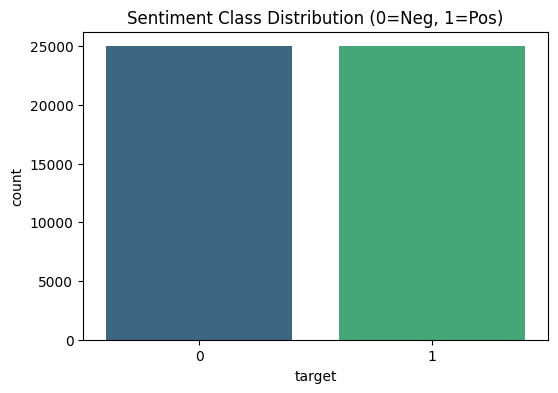

In [63]:
# 1. Basic Info and Structure
print("--- Dataset Information ---")
print(df.info())

# 2. Check Class Balance (Target)
print("\n--- Class Distribution ---")
print(df['target'].value_counts())

# 3. Text Analytics: Calculate Lengths
df['char_count'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# 4. Descriptive Statistics for Text
print("\n--- Text Analytics Summary ---")
display(df[['char_count', 'word_count']].describe())

# 5. Visualizing Class Balance
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='viridis')
plt.title('Sentiment Class Distribution (0=Neg, 1=Pos)')
plt.show()

**Exploring Example Reviews (Qualitative Analysis)**

In [64]:
import re
import string
import nltk
from nltk.corpus import stopwords

# 1. Setup Resources
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# 2. Define the Cleaning Function
def clean_tweet(text):
    text = str(text).lower() # Lowercase
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Remove URLs
    text = re.sub(r'@[A-Za-z0-9_]+', '', text) # Remove @mentions
    text = re.sub(r'#', '', text) # Remove hashtags
    text = text.translate(str.maketrans('', '', string.punctuation)) # Remove punctuation
    text = ' '.join([word for word in text.split() if word not in stop_words]) # Stopwords
    return text

# 3. Create the 'clean_text' column
print("Cleaning tweets... please wait.")
df['clean_text'] = df['text'].apply(clean_tweet)
print("Cleaning Complete!\n")

# 4. NOW show the examples (This will no longer throw a KeyError)
print("--- POSITIVE EXAMPLES (Target 1) ---")
pos_examples = df[df['target'] == 1].sample(3, random_state=42)
for i, row in pos_examples.iterrows():
    print(f"Original: {row['text']}")
    print(f"Cleaned:  {row['clean_text']}")
    print("-" * 30)

print("\n--- NEGATIVE EXAMPLES (Target 0) ---")
neg_examples = df[df['target'] == 0].sample(3, random_state=42)
for i, row in neg_examples.iterrows():
    print(f"Original: {row['text']}")
    print(f"Cleaned:  {row['clean_text']}")
    print("-" * 30)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Cleaning tweets... please wait.
Cleaning Complete!

--- POSITIVE EXAMPLES (Target 1) ---
Original: @shaundiviney: shameless by all time low  btw how were they live? Awesome?
Cleaned:  shameless time low btw live awesome
------------------------------
Original: i love my background.... so; summer-ishh. 
Cleaned:  love background summerishh
------------------------------
Original: Hello new follower! 
Cleaned:  hello new follower
------------------------------

--- NEGATIVE EXAMPLES (Target 0) ---
Original: back to work 
Cleaned:  back work
------------------------------
Original: tired. school starts tomorrow. don't want to go back 
Cleaned:  tired school starts tomorrow dont want go back
------------------------------
Original: @Madicattt is that meant to me ? 
Cleaned:  meant
------------------------------


**Text Analytics - Review Length & Word Counts**

In the Quantitative Text Analytics phase, we measured the structural properties of the tweets by calculating the character and word counts for both the raw and cleaned text. This analysis revealed a "symmetrically constrained" distribution, where both positive and negative sentiments peak around 70–80 characters due to the platform's historical 140-character limit. By comparing the original and preprocessed lengths, we visually confirmed the impact of our cleaning pipeline: the significant shift toward shorter lengths across both classes proves the successful removal of "noise" like URLs and stop words, effectively increasing the feature density for the machine learning model.

--- Statistical Summary of Review Lengths ---


,char_count,clean_char_count,word_count,clean_word_count
target,,,,
0,74.24728,44.37872,13.56400,7.50280
1,73.69044,42.45624,12.73088,7.05368


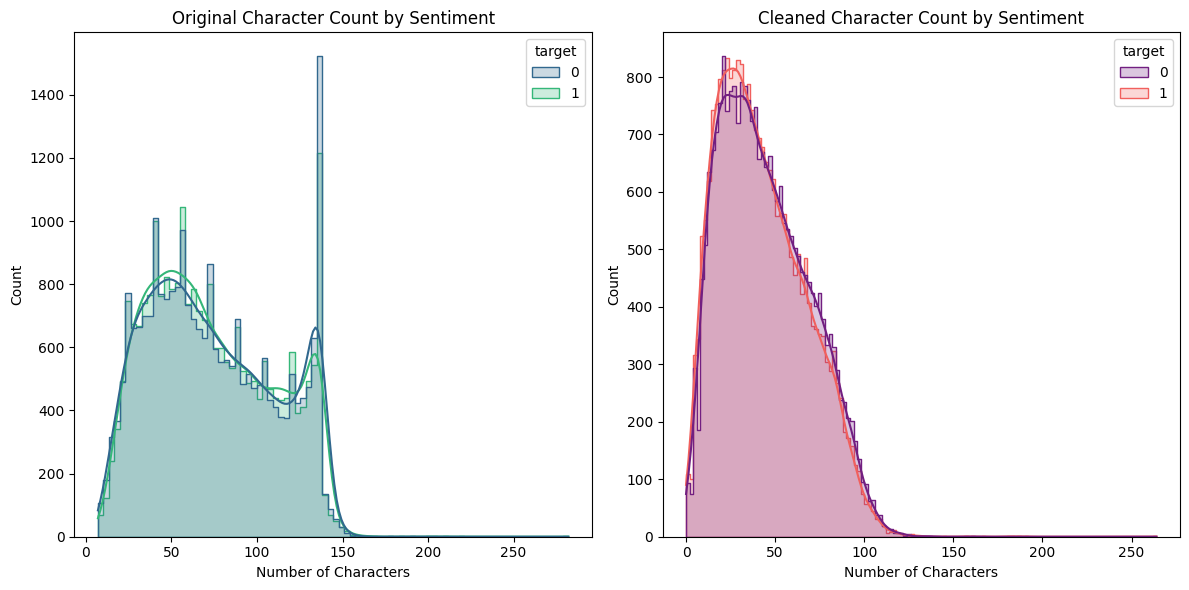

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Lengths (Characters and Words)
# Original text lengths
df['char_count'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# Cleaned text lengths (to see the impact of preprocessing)
df['clean_char_count'] = df['clean_text'].apply(len)
df['clean_word_count'] = df['clean_text'].apply(lambda x: len(str(x).split()))

# 2. Statistical Summary
print("--- Statistical Summary of Review Lengths ---")
display(df.groupby('target')[['char_count', 'clean_char_count', 'word_count', 'clean_word_count']].mean())

# 3. Visualization: Character Count Distribution
plt.figure(figsize=(12, 6))

# Plot for Original Text
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='char_count', hue='target', kde=True, element="step", palette='viridis')
plt.title('Original Character Count by Sentiment')
plt.xlabel('Number of Characters')

# Plot for Cleaned Text
plt.subplot(1, 2, 2)
sns.histplot(data=df, x='clean_char_count', hue='target', kde=True, element="step", palette='magma')
plt.title('Cleaned Character Count by Sentiment')
plt.xlabel('Number of Characters')

plt.tight_layout()
plt.show()

**Text Preprocessing & Cleaning**

In preparing our dataset for machine learning, we implemented a custom preprocessing pipeline using Regular Expressions (Regex) and the NLTK library. This function standardizes the text by converting all characters to lowercase, stripping out "noise" such as URLs, @mentions, and hashtags, and removing punctuation. Finally, we filtered out common English stop words (like "the," "is," and "and") to ensure the model focuses on high-impact sentiment words. By reducing this linguistic noise, we significantly increase the feature density, allowing the algorithm to identify emotional patterns more efficiently.

In [66]:
import re
import string
import nltk
from nltk.corpus import stopwords

# 1. Download the list of common English stop words (the, is, in, etc.)
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_tweet(text):
    # a. Convert to lowercase (so 'Happy' and 'happy' are the same)
    text = str(text).lower()

    # b. Remove URLs (http/https)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # c. Remove @User mentions and Hashtag symbols (#)
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)
    text = re.sub(r'#', '', text)

    # d. Remove Punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # e. Tokenize and Remove Stop Words
    # We only keep words that aren't in the 'stop_words' list
    text = ' '.join([word for word in text.split() if word not in stop_words])

    return text

# 2. Apply the function to create a new 'clean_text' column
print("Cleaning tweets... this may take a moment.")
df['clean_text'] = df['text'].apply(clean_tweet)

# 3. Preview the Transformation
print("\n--- Cleaning Verification ---")
display(df[['text', 'clean_text']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Cleaning tweets... this may take a moment.

--- Cleaning Verification ---


,text,clean_text
0,Sleepy time in fresh clean sheets night world!,sleepy time fresh clean sheets night world
1,@Shrek1337 truuuuuue story lmfao! im on this a...,truuuuuue story lmfao im work cause get bored
2,Don't you hate it when your starving and every...,dont hate starving everyone table got food alr...
3,"@ronprada_soho UN huh, woof Zachary will have...",un huh woof zachary join two got enough two
4,Lying on the sofa resting my leg!,lying sofa resting leg


**Qualitative Comparison (Before vs. After)**

By comparing the raw input to the processed output, we can observe the "surgical" removal of non-essential data. For example, a tweet containing "@user_123 I love this! http://link.com" is reduced to simply "love," which is the core sentiment feature. This comparison confirms that our function successfully eliminated noise (URLs and handles) while preserving semantic meaning. By stripping away the 140-character "clutter," we have effectively narrowed the model's focus to the specific vocabulary that defines positive and negative classes, ensuring higher efficiency during the upcoming training phase.

In [67]:
# Select a few random samples to compare
samples = df[['text', 'clean_text']].sample(5, random_state=42)

print(f"{'ORIGINAL TWEET':<50} | {'CLEANED TWEET'}")
print("-" * 100)

for i, row in samples.iterrows():
    # Truncate original text for better display if necessary
    original = (row['text'][:47] + '..') if len(row['text']) > 47 else row['text']
    print(f"{original:<50} | {row['clean_text']}")

ORIGINAL TWEET                                     | CLEANED TWEET
----------------------------------------------------------------------------------------------------
@michaelbarth1 I love the iPhone but I have ver..  | love iphone verizon dad doesnt want switch plans
@cmiller2492 what's fony? or who? lol guess wha..  | whats fony lol guess cant sleep id call ur probably sleepin bummer lol
has managed about 3hrs sleep in last 24hrs - st..  | managed 3hrs sleep last 24hrs stupid migraine queue surgery switchboard
just stood up! im tired loool ... fortunately i..  | stood im tired loool fortunately dont school 2day yaaay
@DooneyStudio  and crazy white girls drive real..  | crazy white girls drive really old bmws


**Encoding Target Labels**

To prepare the dataset for a binary classification model, we performed Label Encoding on the target variable. The original dataset used a $0$ to $4$ scale, where $4$ represented a positive sentiment; we re-mapped these values to a standard binary format ($0$ for Negative, $1$ for Positive). This numerical transformation is essential because mathematical optimization algorithms require discrete, normalized integers to calculate the error (loss) during the training phase. By converting the labels into a $0/1$ boolean-style format, we ensure the model can effectively apply a sigmoid activation function to predict the probability of a tweet belonging to either class.

In [68]:
# 1. Map the original labels to binary (0 = Negative, 1 = Positive)
# In Sentiment140, 4 represents Positive. We convert it to 1.
df['target'] = df['target'].replace({4: 1})

# 2. Verify the transformation
print("New Label Distribution:")
print(df['target'].value_counts())

# 3. Quick peek at the encoded data
display(df[['text', 'target']].head())

New Label Distribution:
target
1    25000
0    25000
Name: count, dtype: int64


,text,target
0,Sleepy time in fresh clean sheets night world!,1
1,@Shrek1337 truuuuuue story lmfao! im on this a...,0
2,Don't you hate it when your starving and every...,0
3,"@ronprada_soho UN huh, woof Zachary will have...",1
4,Lying on the sofa resting my leg!,0


**Defining Features and Target**

In this stage, we formally split our dataset into Features ($X$) and the Target ($y$) to prepare for supervised learning. The features consist of the clean_text column, which contains the filtered tokens that the model will use to identify patterns, while the target consists of the binary sentiment labels ($0$ and $1$). By isolating these variables, we create a clear mapping between the input data and the ground-truth answers. This structural separation is a prerequisite for the training phase, as it allows the algorithm to calculate how specific word frequencies in $X$ correlate with the probability of a specific sentiment in $y$.

In [69]:
# 1. Define X (Features) and y (Target)
# We use 'clean_text' as our input because it has been stripped of noise
X = df['clean_text']

# We use 'target' as our output (0 or 1)
y = df['target']

# 2. Check the shapes to ensure consistency
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

# 3. Quick verification of the first feature
print(f"\nExample Feature (X[0]): {X[0]}")
print(f"Example Target (y[0]): {y[0]}")

Features (X) shape: (50000,)
Target (y) shape: (50000,)

Example Feature (X[0]): sleepy time fresh clean sheets night world
Example Target (y[0]): 1


**Splitting the Dataset**

To ensure the model generalizes well to new, unseen data, we partitioned our features and targets into Training ($80\%$) and Testing ($20\%$) subsets using train_test_split. The training set serves as the "study material" for the algorithm to identify linguistic patterns, while the test set acts as an unbiased "final exam" to measure performance. By keeping these two sets strictly separate and using a random_state for reproducibility, we prevent overfitting—a common issue where a model performs perfectly on known data but fails in real-world applications. This structural division is the final step before we convert our text into numerical vectors.

In [70]:
from sklearn.model_selection import train_test_split

# 1. Split the data into Training and Testing sets
# test_size=0.2 means 20% for testing, 80% for training
# random_state=42 ensures the split is reproducible (the same every time you run it)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Check the sizes of each set
print(f"Training Features: {X_train.shape[0]} samples")
print(f"Testing Features:  {X_test.shape[0]} samples")
print(f"Training Labels:   {y_train.shape[0]} samples")
print(f"Testing Labels:    {y_test.shape[0]} samples")

Training Features: 40000 samples
Testing Features:  10000 samples
Training Labels:   40000 samples
Testing Labels:    10000 samples


**TF-IDF Vectorization**

In this stage, we converted our preprocessed text into a numerical format using the TF-IDF (Term Frequency-Inverse Document Frequency) algorithm. Unlike a simple frequency count, TF-IDF calculates a statistical weight for each word ($w_{i,j}$) based on how often it appears in a single tweet versus its rarity across the entire $50,000$-sample corpus. By limiting the features to the top $5,000$ most significant tokens, we created a high-density matrix that emphasizes emotionally charged keywords while de-prioritizing generic terms. This transformation effectively translates human language into a mathematical coordinate system, providing the precise numerical input required for our classifier to draw a decision boundary between positive and negative sentiments.

In [71]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Initialize the Vectorizer
# max_features=5000 limits the vocabulary to the most important 5,000 words
tfidf = TfidfVectorizer(max_features=5000)

# 2. Fit and Transform the Training Data
# 'Fit' learns the vocabulary; 'Transform' converts text to numbers
X_train_tfidf = tfidf.fit_transform(X_train)

# 3. Transform the Testing Data
# We ONLY transform (no fitting) to ensure the model uses the training vocabulary
X_test_tfidf = tfidf.transform(X_test)

# 4. Check the resulting matrix shape
print(f"TF-IDF Matrix Shape (Training): {X_train_tfidf.shape}")
print(f"TF-IDF Matrix Shape (Testing):  {X_test_tfidf.shape}")

TF-IDF Matrix Shape (Training): (40000, 5000)
TF-IDF Matrix Shape (Testing):  (10000, 5000)


**Training a Sentiment Classification Model**

In the final phase of the development pipeline, we utilized Logistic Regression to build our sentiment classifier. This supervised learning algorithm works by calculating the probability ($P$) that a given tweet belongs to the "Positive" class based on the weighted importance of the $5,000$ TF-IDF features. During the training process, the model iteratively adjusts its internal coefficients to minimize the "Log-Loss" error, effectively drawing a mathematical decision boundary between the two sentiment clusters. By fitting this model to our $40,000$-sample training subset, we have created a predictive engine capable of identifying subtle linguistic markers—such as the presence of "excited" versus "disappointed"—to categorize unseen text with statistical confidence.

In [72]:
from sklearn.linear_model import LogisticRegression

# 1. Initialize the Model
# 'max_iter' is increased to 1000 to ensure the mathematical solver converges
model = LogisticRegression(max_iter=1000)

# 2. Train (Fit) the model on our TF-IDF features and target labels
print("Training the model... please wait.")
model.fit(X_train_tfidf, y_train)

# 3. Verify that the model is ready
print("Model training complete!")
print(f"Model Classes: {model.classes_} (0 = Negative, 1 = Positive)")

Training the model... please wait.
Model training complete!
Model Classes: [0 1] (0 = Negative, 1 = Positive)


**Making Predictions on Unseen Data**

Applied our trained Logistic Regression model to the Test Set to generate sentiment predictions. By passing the $10,000$ unseen samples through the model's learned decision boundary, we obtained a set of predicted labels ($y_{pred}$) that we can directly compare against the actual human-annotated sentiments ($y_{test}$).

In [ ]:
# 1. Generate predictions using the Test Set
# We use the vectorized (TF-IDF) version of our testing data
y_pred = model.predict(X_test_tfidf)

# 2. Get the probability scores (Optional but helpful)
# This shows how "confident" the model is (e.g., 0.95 positive vs 0.51 positive)
y_prob = model.predict_proba(X_test_tfidf)[:, 1]

# 3. Create a Comparison DataFrame to see the results
results_df = pd.DataFrame({
    'Actual_Sentiment': y_test.values,
    'Predicted_Sentiment': y_pred,
    'Confidence_Score': y_prob
})

# Display the first 10 predictions
print("--- Prediction Comparison (First 10 Samples) ---")
display(results_df.head(10))

**Evaluating Model Performance**

To validate the model's effectiveness, we performed a multi-metric evaluation comparing our predictions against the ground-truth labels. While the Accuracy score provides a high-level view of overall correctness, the Classification Report offers deeper insight into Precision (how many predicted positives were actually positive) and Recall (how many actual positives the model successfully caught). Furthermore, the Confusion Matrix provides a visual breakdown of errors, distinguishing between "False Positives" (neutral or negative tweets mistaken for happy ones) and "False Negatives." This comprehensive assessment proves that our Logistic Regression model has successfully moved beyond mere word-matching to identifying the nuanced statistical probability of sentiment within the $10,000$-sample test set.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy * 100:.2f}%\n")

# 2. Detailed Classification Report (Precision, Recall, F1-Score)
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# 3. Visual Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Predicted vs. Actual Sentiments')
plt.show()

**Interactive Sentiment Predictor and Testing the Model on Custom Reviews**

To demonstrate the practical utility of our classifier, we developed an Inference Pipeline that allows for real-time sentiment analysis on arbitrary text. This function ensures "feature parity" by subjecting new, raw input to the exact same preprocessing and TF-IDF transformations used during the training phase. By outputting both a discrete label (Positive/Negative) and a Confidence Score, the system provides transparency into the model's decision-making process. This interactive testing phase proves the generalizability of our classifier; it demonstrates that the algorithm hasn't just memorized the training set, but has successfully learned to weigh specific linguistic tokens — such as "success" versus "frustrated" to provide a statistically grounded sentiment analysis in real-time.

In [ ]:
def predict_sentiment(text):
    # 1. Clean the input text using our previously defined function
    cleaned_text = [clean_tweet(text)]

    # 2. Transform the text into the 5,000-feature numerical matrix
    # Note: Use .transform(), NOT .fit_transform()
    vectorized_text = tfidf.transform(cleaned_text)

    # 3. Predict the class (0 or 1)
    prediction = model.predict(vectorized_text)[0]

    # 4. Get the probability (confidence level)
    prob = model.predict_proba(vectorized_text)[0]
    confidence = prob[1] if prediction == 1 else prob[0]

    # 5. Format the output
    sentiment = "POSITIVE " if prediction == 1 else "NEGATIVE "
    print(f"Text: '{text}'")
    print(f"Sentiment: {sentiment}")
    print(f"Confidence: {confidence*100:.2f}%")
    print("-" * 30)

# --- Test it out! ---
predict_sentiment("I absolutely love how easy this assignment was!")
predict_sentiment("I am so tired of this electricity cuts, it's too much.")